# Elliptic Envelope (Mahalanobis 거리) — 상세 EDA

Robust MCD로 labeled 양품의 공분산 행렬을 추정하고, Mahalanobis 거리를 이상 점수로 사용한다. NB08 전체 기법 중 최고 성능(ROC=0.8938)이었지만, labeled 양품을 학습에 사용한다는 점에서 완전 비지도 기법과 성격이 다르다. pseudo-label로 생성된 '불량'이 기계정지 상태에 오염된 경위와 Step 4 실패 원인도 함께 분석한다.

In [1]:
NB_NAME = 'Elliptic Envelope (Mahalanobis 거리)'
NB_PRE  = 'NB08h'

## 0. 환경 설정

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from pathlib import Path
from scipy.stats import ks_2samp
from time import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.mixture import GaussianMixture
from sklearn.svm import OneClassSVM
from sklearn.cluster import MiniBatchKMeans

try:
    import umap as umap_lib; HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

try:
    from pyod.models.hbos import HBOS
    from pyod.models.copod import COPOD
    from pyod.models.knn import KNN as PyODKNN
    HAS_PYOD = True
except ImportError:
    HAS_PYOD = False

SEED = 42
np.random.seed(SEED)
BASE = Path(r'E:\\IAAI_Term_project')
FIG_DIR = BASE / 'results/figures'
TAB_DIR = BASE / 'results/tables'
FIG_DIR.mkdir(exist_ok=True, parents=True)
TAB_DIR.mkdir(exist_ok=True, parents=True)

def setup_korean_font():
    import matplotlib.font_manager as fm
    for f in fm.fontManager.ttflist:
        if 'Malgun' in f.name:
            plt.rcParams['font.family'] = f.name; break
    plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid')
setup_korean_font()
print(f"Setup OK | pyod:{HAS_PYOD} | umap:{HAS_UMAP}")

Setup OK | pyod:True | umap:True


## 1. 데이터 로드 + CN7/RG3 필터링

In [3]:
print("Loading data...")
lab   = pd.read_csv(BASE / 'data/raw/labeled_data.csv')
lab['label'] = (lab['PassOrFail'] == 'N').astype(int)
unlab = pd.read_csv(BASE / 'data/raw/unlabeled_data.csv')

ZERO_VAR = ['Mold_Temperature_1','Mold_Temperature_2','Mold_Temperature_5',
    'Mold_Temperature_6','Mold_Temperature_7','Mold_Temperature_8',
    'Mold_Temperature_9','Mold_Temperature_10','Mold_Temperature_11',
    'Mold_Temperature_12','Barrel_Temperature_7']
META = {'_id','Unnamed: 0','TimeStamp','PART_FACT_PLAN_DATE','PART_FACT_SERIAL',
        'PART_NAME','EQUIP_CD','EQUIP_NAME','PassOrFail','Reason','ERR_FACT_QTY','label'}

eq_vals = set(lab['EQUIP_NAME'].unique())
cn7rg3  = [p for p in lab['PART_NAME'].unique() if 'CN7' in p or 'RG3' in p]
unf     = unlab[unlab['EQUIP_NAME'].isin(eq_vals) & unlab['PART_NAME'].isin(cn7rg3)].reset_index(drop=True)

fcols = [c for c in lab.columns if c not in META and c not in ZERO_VAR
         and lab[c].dtype in ['float64','int64','float32','int32']]
X_lab = lab[fcols].values.astype(float); y_lab = lab['label'].values
mask_n = y_lab==0; mask_d = y_lab==1
X_unl  = unf[[c for c in fcols if c in unf.columns]].fillna(0).values.astype(float)
DR     = y_lab.mean()

sc = StandardScaler(); Xu = sc.fit_transform(X_unl); Xl = sc.transform(X_lab)
print(f"Labeled  : {len(X_lab):,} (불량 {mask_d.sum()}, 양품 {mask_n.sum()})")
print(f"Unlabeled: {len(X_unl):,} (CN7/RG3 필터) | DR={DR*100:.4f}%")
print(f"Features : {fcols}")

Loading data...


Labeled  : 7,996 (불량 71, 양품 7925)
Unlabeled: 71,180 (CN7/RG3 필터) | DR=0.8879%
Features : ['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']


## 2. PCA 2D + 3D 시각화 (데이터 구조 파악)

PCA: PC1=58.8%  PC2=19.7%  PC3=10.2%  cum=88.8%


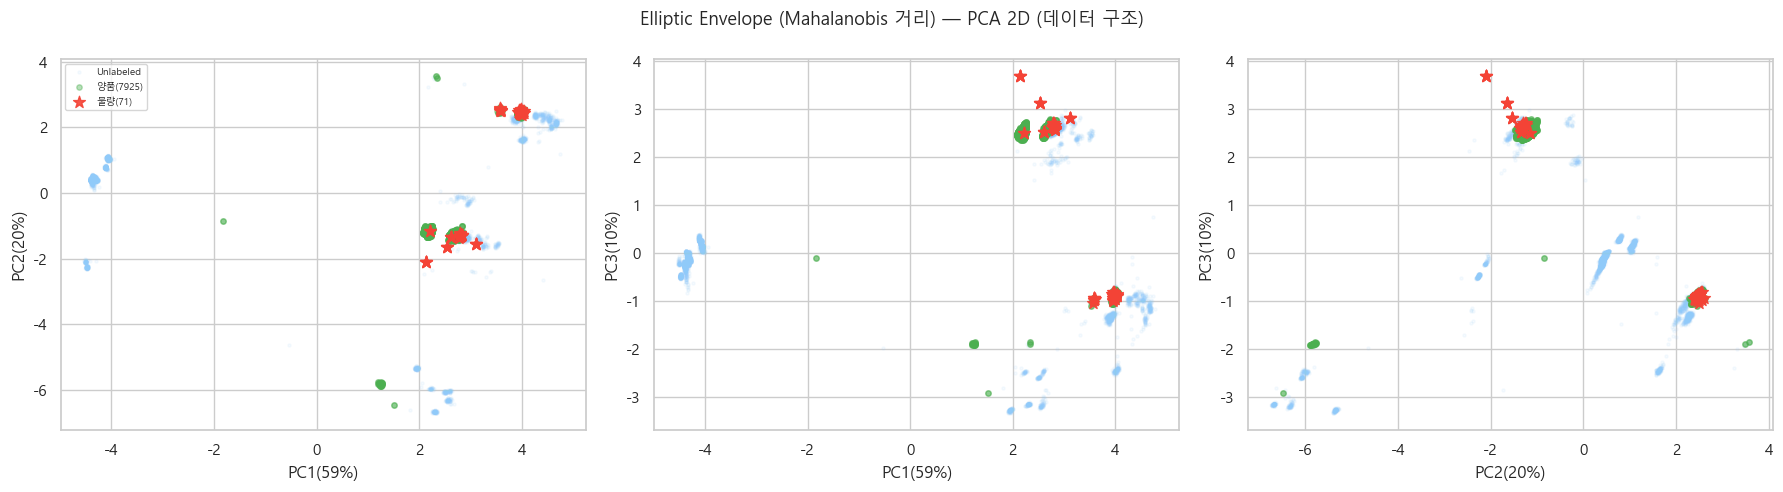

PCA 2D 저장 완료


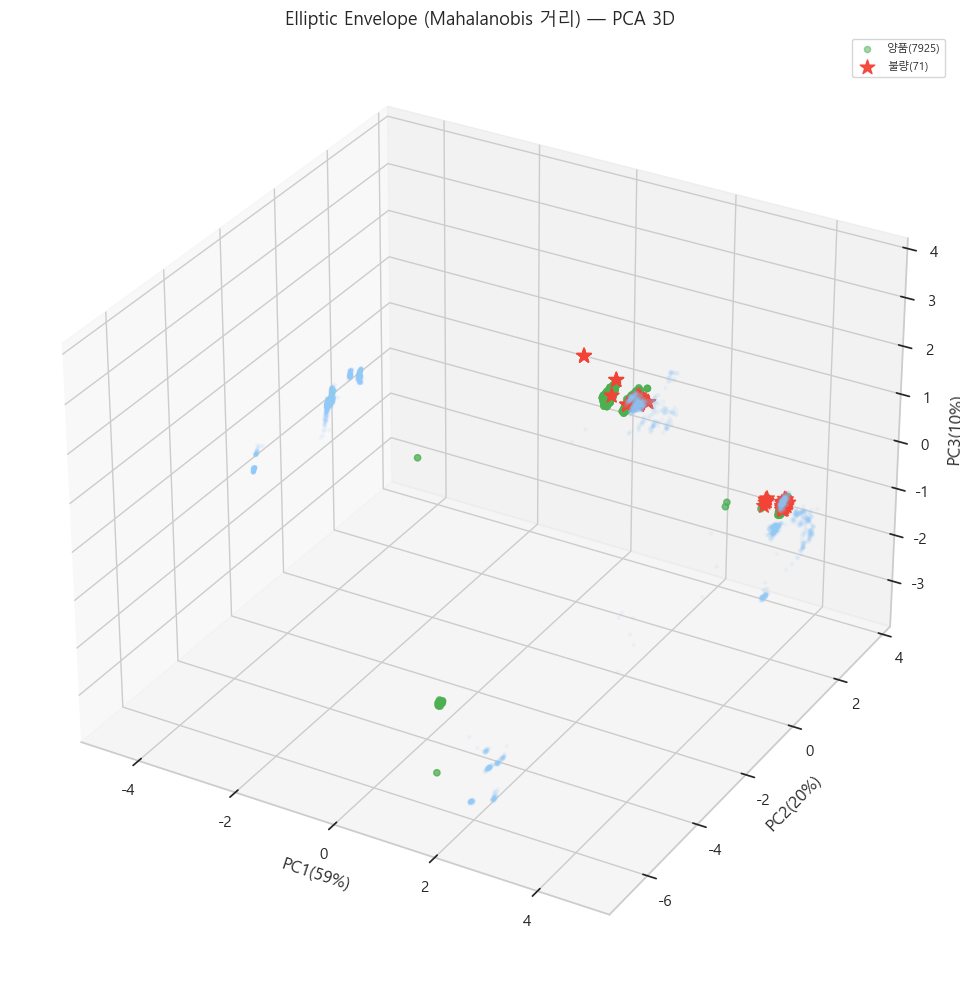

PCA 3D 저장 완료

▶ 불량의 PCA 공간 위치:
  PC1: 불량[2.14,4.04]  양품[-1.83,4.06]  불량 양품범위내: 71/71
  PC2: 불량[-2.09,2.59]  양품[-6.47,3.57]  불량 양품범위내: 71/71
  PC3: 불량[-1.05,3.69]  양품[-2.92,2.80]  불량 양품범위내: 59/71


In [4]:
pca = PCA(n_components=3, random_state=SEED)
pca.fit(Xu); Xu_p = pca.transform(Xu); Xl_p = pca.transform(Xl)
evr = pca.explained_variance_ratio_
print(f"PCA: PC1={evr[0]*100:.1f}%  PC2={evr[1]*100:.1f}%  PC3={evr[2]*100:.1f}%  cum={evr[:3].sum()*100:.1f}%")

# ── 2D ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,3,figsize=(18,5))
fig.suptitle(f'{NB_NAME} — PCA 2D (데이터 구조)', fontsize=13)
for ax,(i,j) in zip(axes,[(0,1),(0,2),(1,2)]):
    s=max(1,len(Xu_p)//4000)
    ax.scatter(Xu_p[::s,i],Xu_p[::s,j],alpha=0.08,s=5,c='#90CAF9',label='Unlabeled')
    ax.scatter(Xl_p[mask_n,i],Xl_p[mask_n,j],alpha=0.4,s=15,c='#4CAF50',label=f'양품({mask_n.sum()})',zorder=3)
    ax.scatter(Xl_p[mask_d,i],Xl_p[mask_d,j],alpha=0.9,s=80,c='#F44336',marker='*',label=f'불량({mask_d.sum()})',zorder=4)
    ax.set_xlabel(f'PC{i+1}({evr[i]*100:.0f}%)'); ax.set_ylabel(f'PC{j+1}({evr[j]*100:.0f}%)')
    if i==0 and j==1: ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_pca2d.png',dpi=150,bbox_inches='tight')
plt.show(); print("PCA 2D 저장 완료")

# ── 3D ──────────────────────────────────────────────────────────────────────
fig=plt.figure(figsize=(13,10)); ax3=fig.add_subplot(111,projection='3d')
s=max(1,len(Xu_p)//3000)
ax3.scatter(Xu_p[::s,0],Xu_p[::s,1],Xu_p[::s,2],alpha=0.07,s=5,c='#90CAF9')
ax3.scatter(Xl_p[mask_n,0],Xl_p[mask_n,1],Xl_p[mask_n,2],alpha=0.5,s=20,c='#4CAF50',label=f'양품({mask_n.sum()})',zorder=3)
ax3.scatter(Xl_p[mask_d,0],Xl_p[mask_d,1],Xl_p[mask_d,2],alpha=0.95,s=120,c='#F44336',marker='*',label=f'불량({mask_d.sum()})',zorder=4)
ax3.set_xlabel(f'PC1({evr[0]*100:.0f}%)'); ax3.set_ylabel(f'PC2({evr[1]*100:.0f}%)'); ax3.set_zlabel(f'PC3({evr[2]*100:.0f}%)')
ax3.set_title(f'{NB_NAME} — PCA 3D',fontsize=13); ax3.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_pca3d.png',dpi=150,bbox_inches='tight')
plt.show(); print("PCA 3D 저장 완료")

# ── 불량 PCA 위치 분석 ───────────────────────────────────────────────────────
print("\n▶ 불량의 PCA 공간 위치:")
for nm,col in [('PC1',0),('PC2',1),('PC3',2)]:
    d_r = [Xl_p[mask_d,col].min(), Xl_p[mask_d,col].max()]
    n_r = [Xl_p[mask_n,col].min(), Xl_p[mask_n,col].max()]
    overlap = np.sum((Xl_p[mask_d,col]>=n_r[0])&(Xl_p[mask_d,col]<=n_r[1]))
    print(f"  {nm}: 불량[{d_r[0]:.2f},{d_r[1]:.2f}]  양품[{n_r[0]:.2f},{n_r[1]:.2f}]  불량 양품범위내: {overlap}/{mask_d.sum()}")

## 3. UMAP 2D + 3D 시각화

UMAP 2D fitting...


  done in 19.6s


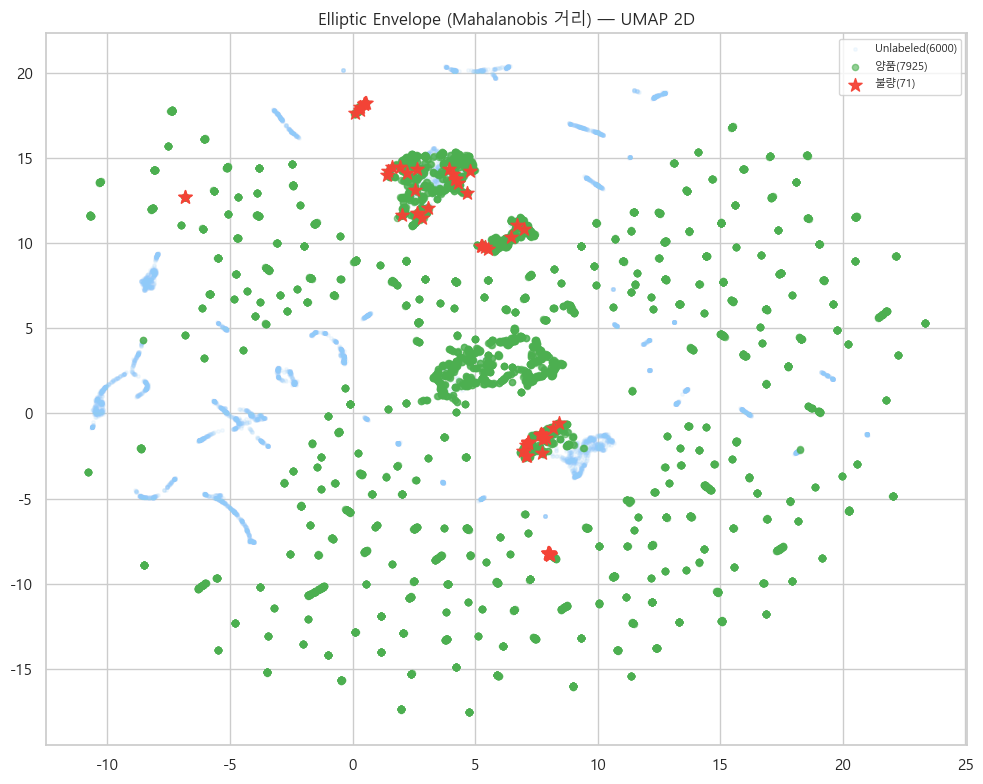

UMAP 2D 저장 완료
UMAP 3D fitting...


  done in 5.7s


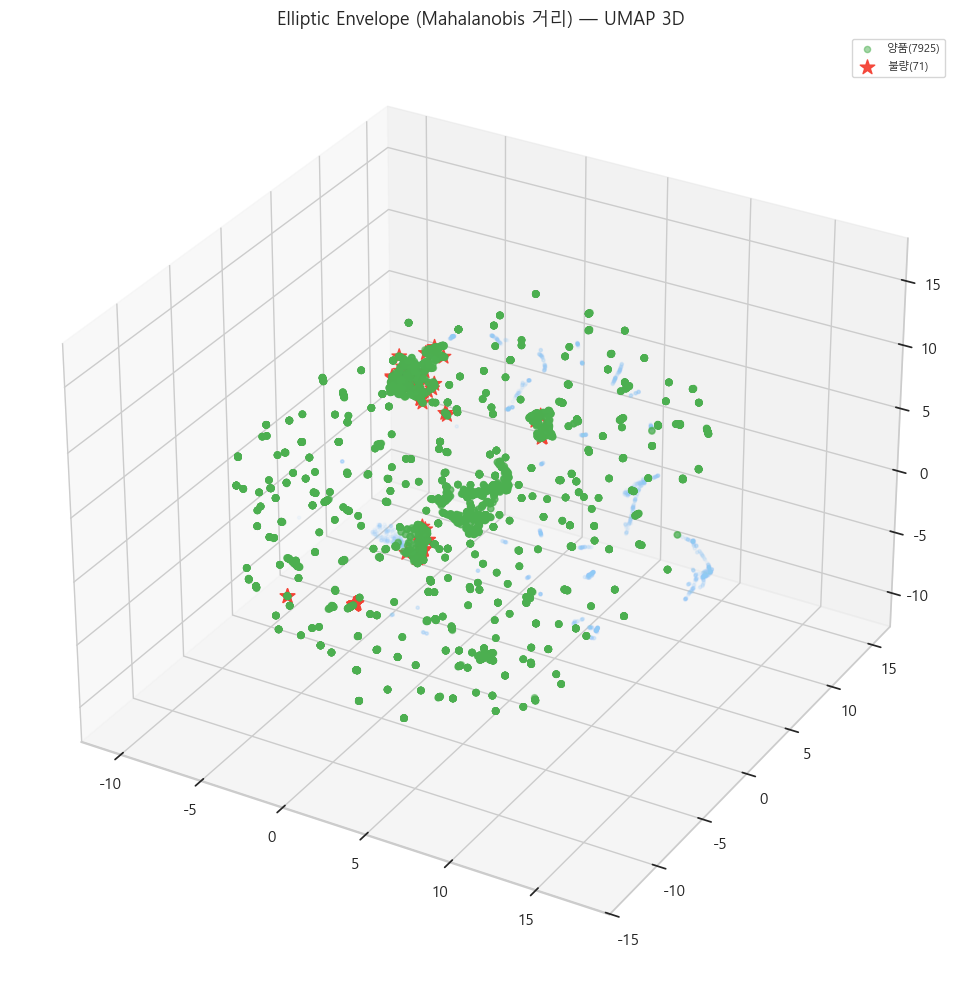

UMAP 3D 저장 완료

▶ UMAP 2D 군집 퍼짐: 불량=9.982  양품=10.581  비율=0.94x
  → 불량이 비교적 군집


In [5]:
N_U = 6000
rng_u = np.random.RandomState(SEED)
idx_u = rng_u.choice(len(Xu), N_U, replace=False)
Xcomb = np.vstack([Xu[idx_u], Xl])

if HAS_UMAP:
    # ── UMAP 2D ─────────────────────────────────────────────────────────────
    print("UMAP 2D fitting..."); t0=time()
    r2 = umap_lib.UMAP(n_components=2,random_state=SEED,n_neighbors=15,min_dist=0.1,verbose=False)
    U2 = r2.fit_transform(Xcomb); U2u=U2[:N_U]; U2l=U2[N_U:]
    print(f"  done in {time()-t0:.1f}s")
    fig,ax=plt.subplots(figsize=(10,8))
    ax.scatter(U2u[:,0],U2u[:,1],alpha=0.1,s=6,c='#90CAF9',label=f'Unlabeled({N_U})')
    ax.scatter(U2l[mask_n,0],U2l[mask_n,1],alpha=0.6,s=20,c='#4CAF50',label=f'양품({mask_n.sum()})',zorder=3)
    ax.scatter(U2l[mask_d,0],U2l[mask_d,1],alpha=0.95,s=100,c='#F44336',marker='*',label=f'불량({mask_d.sum()})',zorder=4)
    ax.set_title(f'{NB_NAME} — UMAP 2D'); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR/f'{NB_PRE}_fig_umap2d.png',dpi=150,bbox_inches='tight')
    plt.show(); print("UMAP 2D 저장 완료")

    # ── UMAP 3D ─────────────────────────────────────────────────────────────
    print("UMAP 3D fitting..."); t0=time()
    r3 = umap_lib.UMAP(n_components=3,random_state=SEED,n_neighbors=15,min_dist=0.1,verbose=False)
    U3 = r3.fit_transform(Xcomb); U3u=U3[:N_U]; U3l=U3[N_U:]
    print(f"  done in {time()-t0:.1f}s")
    fig=plt.figure(figsize=(13,10)); ax3=fig.add_subplot(111,projection='3d')
    s=max(1,N_U//2000)
    ax3.scatter(U3u[::s,0],U3u[::s,1],U3u[::s,2],alpha=0.07,s=5,c='#90CAF9')
    ax3.scatter(U3l[mask_n,0],U3l[mask_n,1],U3l[mask_n,2],alpha=0.5,s=20,c='#4CAF50',label=f'양품({mask_n.sum()})',zorder=3)
    ax3.scatter(U3l[mask_d,0],U3l[mask_d,1],U3l[mask_d,2],alpha=0.95,s=120,c='#F44336',marker='*',label=f'불량({mask_d.sum()})',zorder=4)
    ax3.set_title(f'{NB_NAME} — UMAP 3D',fontsize=13); ax3.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR/f'{NB_PRE}_fig_umap3d.png',dpi=150,bbox_inches='tight')
    plt.show(); print("UMAP 3D 저장 완료")
    # 불량 분산 분석
    dc = U2l[mask_d].mean(axis=0); nc = U2l[mask_n].mean(axis=0)
    d_sp = np.sqrt(((U2l[mask_d]-dc)**2).sum(axis=1)).mean()
    n_sp = np.sqrt(((U2l[mask_n]-nc)**2).sum(axis=1)).mean()
    print(f"\n▶ UMAP 2D 군집 퍼짐: 불량={d_sp:.3f}  양품={n_sp:.3f}  비율={d_sp/n_sp:.2f}x")
    print(f"  → {'불량이 산재 — 단일 클러스터 없음' if d_sp/n_sp>1.2 else '불량이 비교적 군집'}")
else:
    U2l = U3l = U2u = U3u = None; print("UMAP not available")

## 4. Elliptic Envelope (Mahalanobis 거리) — 하이퍼파라미터 탐색

In [6]:
print("Elliptic Envelope — support_fraction 탐색")
rows=[]
for sf in [0.7,0.8,0.85,0.9,0.95,0.99]:
    try:
        clf=EllipticEnvelope(contamination=DR,random_state=SEED,support_fraction=sf)
        clf.fit(Xl[mask_n])
        sc_=-clf.score_samples(Xl)
        roc=roc_auc_score(y_lab,sc_); pr=average_precision_score(y_lab,sc_)
        rows.append({'support_fraction':sf,'ROC':roc,'PR':pr})
        print(f"  support_fraction={sf}  ROC={roc:.4f}  PR={pr:.4f}")
    except Exception as e:
        print(f"  support_fraction={sf}  ERROR: {e}")
sw_df=pd.DataFrame(rows); print("\n",sw_df.to_string(index=False))
best_sf=sw_df.loc[sw_df['ROC'].idxmax(),'support_fraction']
print(f"\n최적 support_fraction={best_sf}")

Elliptic Envelope — support_fraction 탐색


  support_fraction=0.7  ROC=0.8668  PR=0.0434


  support_fraction=0.8  ROC=0.8668  PR=0.0436


  support_fraction=0.85  ROC=0.8628  PR=0.0432


  support_fraction=0.9  ROC=0.8938  PR=0.1397


  support_fraction=0.95  ROC=0.8931  PR=0.1372


  support_fraction=0.99  ROC=0.8781  PR=0.1361

  support_fraction      ROC       PR
             0.70 0.866766 0.043434
             0.80 0.866762 0.043600
             0.85 0.862813 0.043246
             0.90 0.893819 0.139710
             0.95 0.893106 0.137158
             0.99 0.878078 0.136084

최적 support_fraction=0.9


## 5. 최적 모델 학습 + 이상 점수 계산

In [7]:
clf=EllipticEnvelope(contamination=DR,random_state=SEED,support_fraction=float(best_sf))
clf.fit(Xl[mask_n]); sc_lab=-clf.score_samples(Xl); sc_unl=-clf.score_samples(Xu)
roc=roc_auc_score(y_lab,sc_lab)
print(f"Elliptic Envelope (sf={best_sf}) 완료 | ROC={roc:.4f}")

# pseudo-label 생성 및 검증 (NB08 Step3 재현)
thresh=np.percentile(sc_unl,(1-DR)*100)
pseudo_d=(sc_unl>=thresh)
print(f"\n▶ Pseudo-label 생성 (contamination={DR*100:.4f}%):")
print(f"  Unlabeled {len(Xu):,}행 중 불량 후보: {pseudo_d.sum():,}개")

# 핵심 진단: pseudo-defect 피처 평균 vs labeled 불량
X_pseudo=Xu[pseudo_d]  # 원본 스케일이 아닌 스케일된 값 (Xu=Xu_sc)
X_pseudo_raw=X_unl[pseudo_d]
comp=pd.DataFrame({'Pseudo-불량 평균':X_pseudo_raw.mean(axis=0),
                   'Labeled-불량 평균':X_lab[mask_d].mean(axis=0),
                   'Labeled-양품 평균':X_lab[mask_n].mean(axis=0)},index=fcols)
print(f"\n▶ Pseudo-defect vs Labeled 불량 핵심 피처 비교:")
print(f"  {'피처':<30} {'Pseudo':<10} {'Lab불량':<10} {'Lab양품':<10}")
print("  "+"-"*62)
for f in fcols:
    pv=comp.loc[f,'Pseudo-불량 평균']; dv=comp.loc[f,'Labeled-불량 평균']
    nv=comp.loc[f,'Labeled-양품 평균']
    flag='★기계정지★' if abs(pv)<5 and abs(dv)>20 else ''
    if abs(pv-dv)/(abs(dv)+1e-9)>0.5:
        print(f"  {f:<30} {pv:10.2f} {dv:10.2f} {nv:10.2f}  {flag}")

Elliptic Envelope (sf=0.9) 완료 | ROC=0.8938

▶ Pseudo-label 생성 (contamination=0.8879%):
  Unlabeled 71,180행 중 불량 후보: 633개

▶ Pseudo-defect vs Labeled 불량 핵심 피처 비교:
  피처                             Pseudo     Lab불량      Lab양품     
  --------------------------------------------------------------
  Filling_Time                         5.75       3.29       3.90  
  Plasticizing_Time                    2.97      15.06      16.22  
  Clamp_Close_Time                     3.30       6.99       7.06  
  Cushion_Position                    17.13     653.80     653.40  
  Switch_Over_Position                17.18       0.00       0.33  
  Max_Injection_Speed                 28.42      86.03      66.75  
  Max_Screw_RPM                        0.00      30.79      30.70  ★기계정지★
  Average_Screw_RPM                    0.00     258.39     148.04  ★기계정지★
  Max_Back_Pressure                    4.05      49.08      40.63  ★기계정지★
  Average_Back_Pressure                0.00      62.42      59.55  ★기계정지★
  B

## 6. 이상 점수 PCA/UMAP 2D+3D overlay

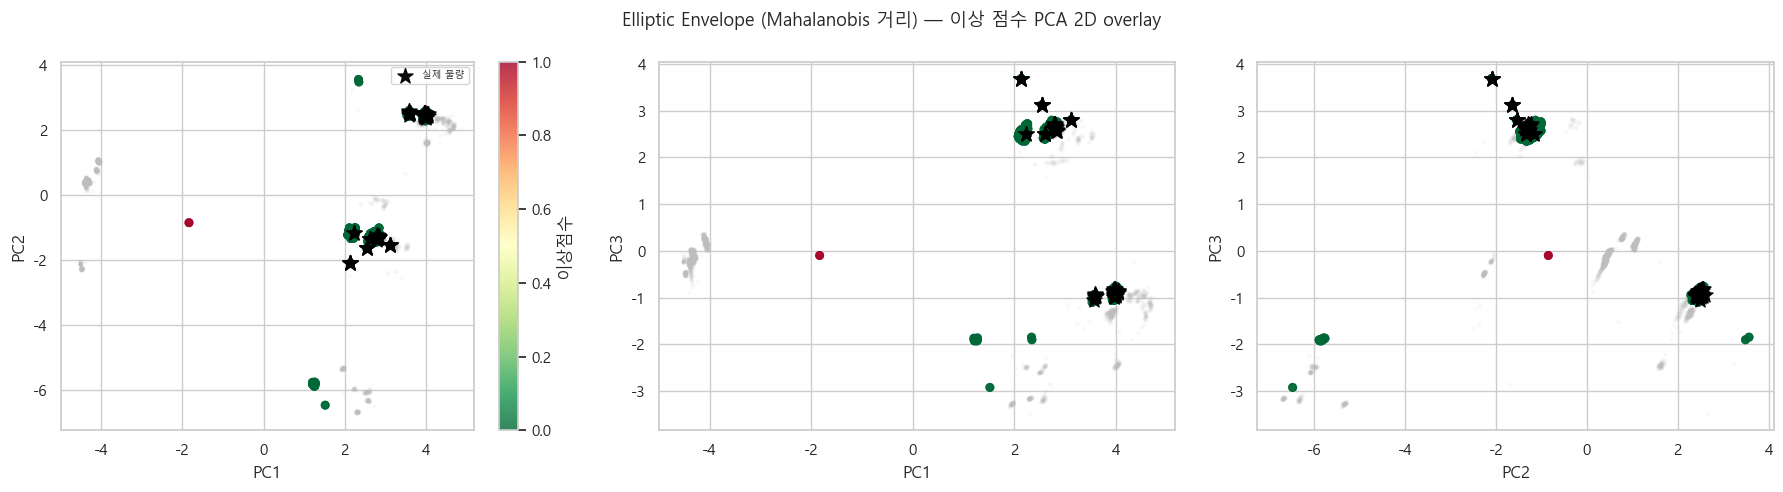

이상점수 PCA 2D 저장 완료


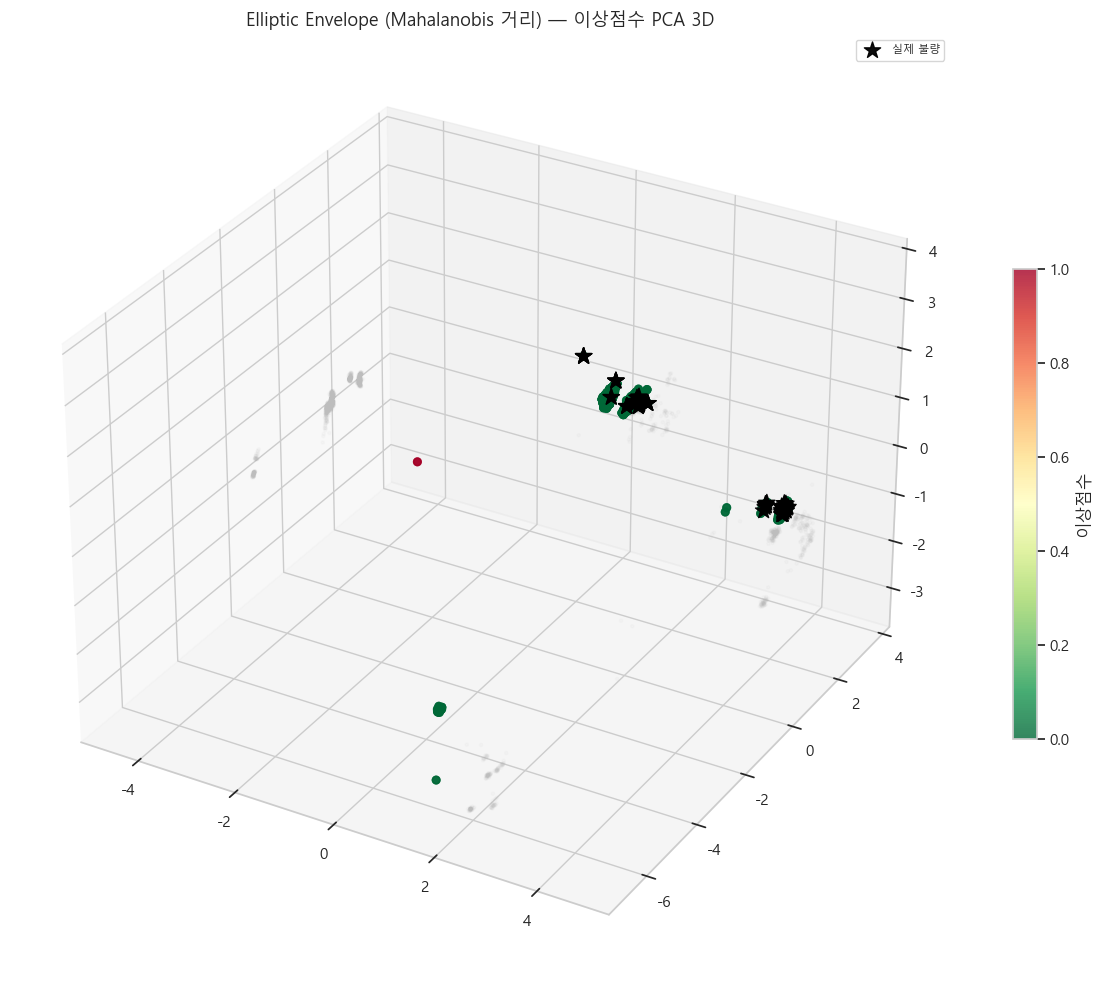

이상점수 PCA 3D 저장 완료


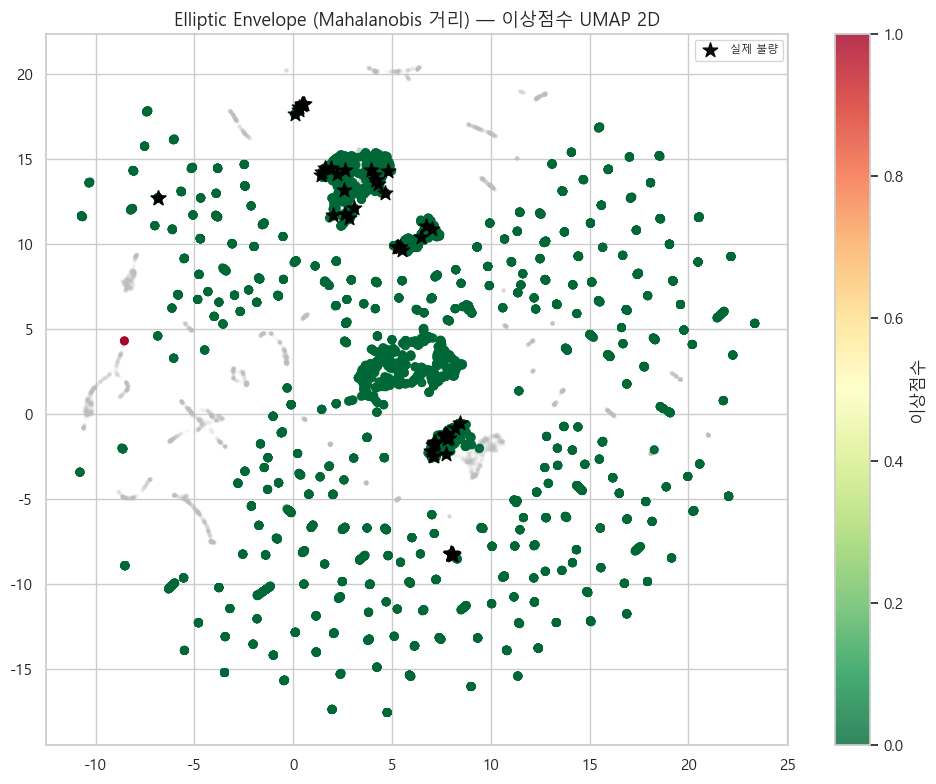

이상점수 UMAP 2D 저장 완료


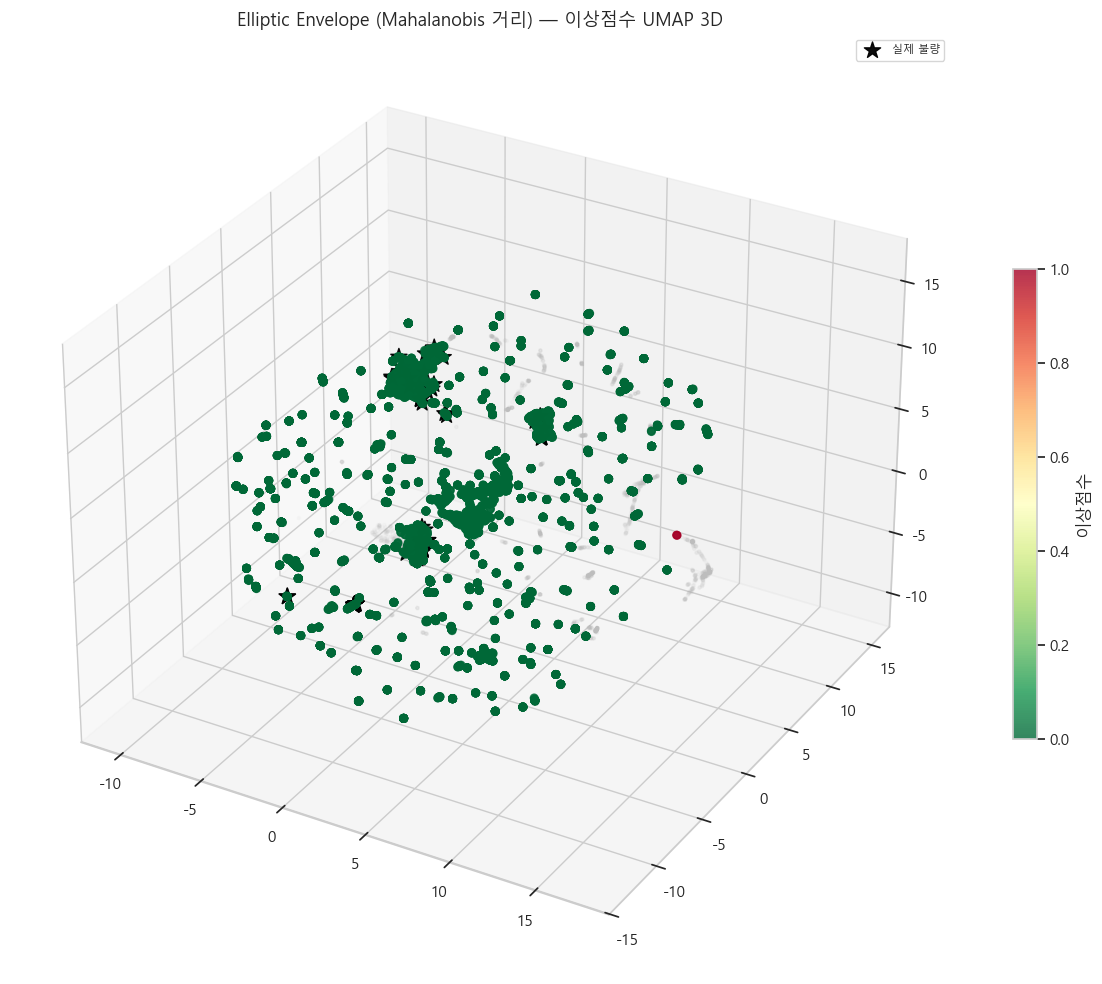

이상점수 UMAP 3D 저장 완료


In [8]:
# 정규화
ns = (sc_lab - sc_lab.min())/(sc_lab.max()-sc_lab.min()+1e-9)

# ── 이상 점수 PCA 2D overlay ─────────────────────────────────────────────────
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle(f'{NB_NAME} — 이상 점수 PCA 2D overlay',fontsize=13)
for ax,(i,j) in zip(axes,[(0,1),(0,2),(1,2)]):
    s=max(1,len(Xu_p)//3000)
    ax.scatter(Xu_p[::s,i],Xu_p[::s,j],alpha=0.05,s=5,c='#BDBDBD')
    sc_=ax.scatter(Xl_p[:,i],Xl_p[:,j],c=ns,cmap='RdYlGn_r',alpha=0.8,s=30,zorder=3,vmin=0,vmax=1)
    ax.scatter(Xl_p[mask_d,i],Xl_p[mask_d,j],alpha=0.95,s=130,c='black',marker='*',zorder=5,label='실제 불량')
    ax.set_xlabel(f'PC{i+1}'); ax.set_ylabel(f'PC{j+1}')
    if i==0 and j==1: plt.colorbar(sc_,ax=ax,label='이상점수'); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_score_pca2d.png',dpi=150,bbox_inches='tight')
plt.show(); print("이상점수 PCA 2D 저장 완료")

# ── 이상 점수 PCA 3D overlay ─────────────────────────────────────────────────
fig=plt.figure(figsize=(13,10)); ax3=fig.add_subplot(111,projection='3d')
s=max(1,len(Xu_p)//2000)
ax3.scatter(Xu_p[::s,0],Xu_p[::s,1],Xu_p[::s,2],alpha=0.05,s=5,c='#BDBDBD')
p3=ax3.scatter(Xl_p[:,0],Xl_p[:,1],Xl_p[:,2],c=ns,cmap='RdYlGn_r',alpha=0.8,s=30,zorder=3,vmin=0,vmax=1)
ax3.scatter(Xl_p[mask_d,0],Xl_p[mask_d,1],Xl_p[mask_d,2],alpha=0.95,s=150,c='black',marker='*',zorder=5,label='실제 불량')
plt.colorbar(p3,ax=ax3,label='이상점수',shrink=0.5)
ax3.set_title(f'{NB_NAME} — 이상점수 PCA 3D',fontsize=13); ax3.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_score_pca3d.png',dpi=150,bbox_inches='tight')
plt.show(); print("이상점수 PCA 3D 저장 완료")

# ── 이상 점수 UMAP overlay ──────────────────────────────────────────────────
if HAS_UMAP and U2l is not None:
    fig,ax=plt.subplots(figsize=(10,8))
    ax.scatter(U2u[:,0],U2u[:,1],alpha=0.05,s=5,c='#BDBDBD')
    sc_=ax.scatter(U2l[:,0],U2l[:,1],c=ns,cmap='RdYlGn_r',alpha=0.8,s=30,zorder=3,vmin=0,vmax=1)
    ax.scatter(U2l[mask_d,0],U2l[mask_d,1],alpha=0.95,s=120,c='black',marker='*',zorder=5,label='실제 불량')
    plt.colorbar(sc_,ax=ax,label='이상점수')
    ax.set_title(f'{NB_NAME} — 이상점수 UMAP 2D',fontsize=13); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR/f'{NB_PRE}_fig_score_umap2d.png',dpi=150,bbox_inches='tight')
    plt.show(); print("이상점수 UMAP 2D 저장 완료")

    fig=plt.figure(figsize=(13,10)); ax3=fig.add_subplot(111,projection='3d')
    s=max(1,N_U//2000)
    ax3.scatter(U3u[::s,0],U3u[::s,1],U3u[::s,2],alpha=0.05,s=5,c='#BDBDBD')
    p3=ax3.scatter(U3l[:,0],U3l[:,1],U3l[:,2],c=ns,cmap='RdYlGn_r',alpha=0.8,s=30,zorder=3,vmin=0,vmax=1)
    ax3.scatter(U3l[mask_d,0],U3l[mask_d,1],U3l[mask_d,2],alpha=0.95,s=150,c='black',marker='*',zorder=5,label='실제 불량')
    plt.colorbar(p3,ax=ax3,label='이상점수',shrink=0.5)
    ax3.set_title(f'{NB_NAME} — 이상점수 UMAP 3D',fontsize=13); ax3.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR/f'{NB_PRE}_fig_score_umap3d.png',dpi=150,bbox_inches='tight')
    plt.show(); print("이상점수 UMAP 3D 저장 완료")

## 7. 이상 점수 분포 + KS 검정

Elliptic Envelope (Mahalanobis 거리) — 성능 지표
  ROC-AUC : 0.8938
  PR-AUC  : 0.1397
  KS 통계 : 0.6345  p=0.0000  유의(p<0.05)
  분리 등급: ★★★ 우수(KS>0.4)

  양품(7925) 점수: mean=3798438.9447  median=23.4209  std=238187654.6674
  불량(71) 점수: mean=28412.5501  median=183.3002  std=80439.7834
  양품 Q1/Q2/Q3: 19.0875 / 23.4209 / 30.9028
  불량 Q1/Q2/Q3: 42.2115 / 183.3002 / 5469.1859


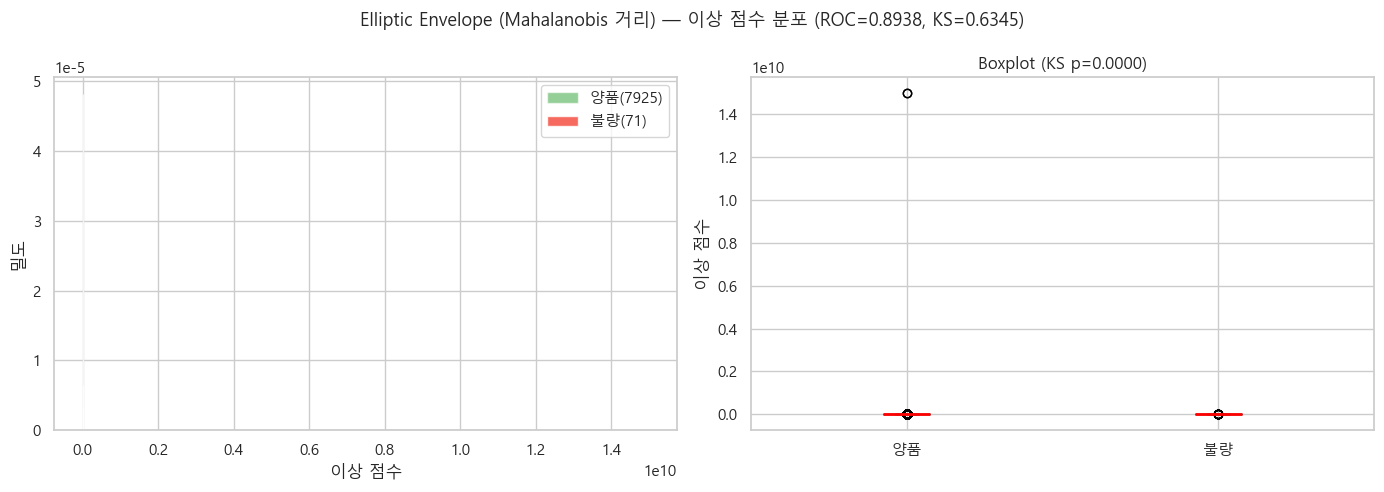

분포 저장 완료


In [9]:
roc = roc_auc_score(y_lab, sc_lab); pr = average_precision_score(y_lab, sc_lab)
ks, kp = ks_2samp(sc_lab[mask_n], sc_lab[mask_d])
print("="*60)
print(f"{NB_NAME} — 성능 지표")
print("="*60)
print(f"  ROC-AUC : {roc:.4f}")
print(f"  PR-AUC  : {pr:.4f}")
print(f"  KS 통계 : {ks:.4f}  p={kp:.4f}  {'유의(p<0.05)' if kp<0.05 else '비유의'}")
print(f"  분리 등급: {'★★★ 우수(KS>0.4)' if ks>0.4 else '★★ 양호(KS>0.25)' if ks>0.25 else '★ 약함(KS>0.1)' if ks>0.1 else '✗ 분리불가'}")
print()
print(f"  양품({mask_n.sum()}) 점수: mean={sc_lab[mask_n].mean():.4f}  median={np.median(sc_lab[mask_n]):.4f}  std={sc_lab[mask_n].std():.4f}")
print(f"  불량({mask_d.sum()}) 점수: mean={sc_lab[mask_d].mean():.4f}  median={np.median(sc_lab[mask_d]):.4f}  std={sc_lab[mask_d].std():.4f}")
mn_q = np.percentile(sc_lab[mask_n],[25,50,75]); md_q = np.percentile(sc_lab[mask_d],[25,50,75])
print(f"  양품 Q1/Q2/Q3: {mn_q[0]:.4f} / {mn_q[1]:.4f} / {mn_q[2]:.4f}")
print(f"  불량 Q1/Q2/Q3: {md_q[0]:.4f} / {md_q[1]:.4f} / {md_q[2]:.4f}")

fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle(f'{NB_NAME} — 이상 점수 분포 (ROC={roc:.4f}, KS={ks:.4f})',fontsize=13)
axes[0].hist(sc_lab[mask_n],bins=50,density=True,color='#4CAF50',alpha=0.6,label=f'양품({mask_n.sum()})')
axes[0].hist(sc_lab[mask_d],bins=20,density=True,color='#F44336',alpha=0.8,label=f'불량({mask_d.sum()})')
axes[0].set_xlabel('이상 점수'); axes[0].set_ylabel('밀도'); axes[0].legend()
axes[1].boxplot([sc_lab[mask_n],sc_lab[mask_d]],labels=['양품','불량'],patch_artist=True,
                boxprops={'facecolor':'#E3F2FD'},medianprops={'color':'red','linewidth':2})
axes[1].set_ylabel('이상 점수'); axes[1].set_title(f'Boxplot (KS p={kp:.4f})')
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_dist.png',dpi=150,bbox_inches='tight')
plt.show(); print("분포 저장 완료")

## 7b. ROC / PR 곡선

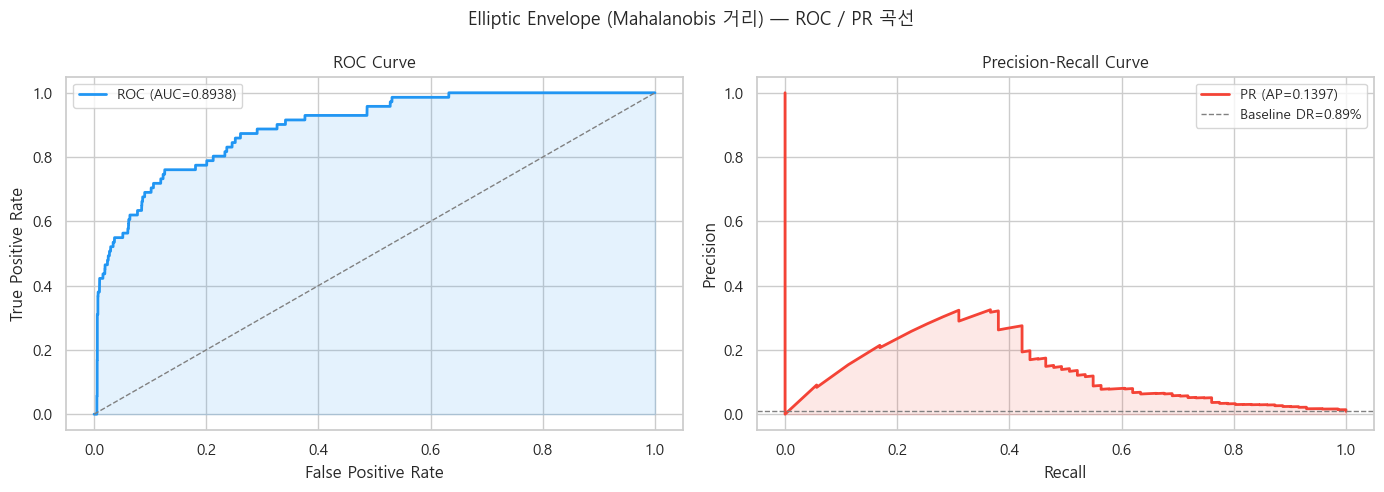

ROC/PR 곡선 저장 완료


In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve
fpr,tpr,_ = roc_curve(y_lab,sc_lab)
prec_c,rec_c,_ = precision_recall_curve(y_lab,sc_lab)
roc=roc_auc_score(y_lab,sc_lab); pr=average_precision_score(y_lab,sc_lab)
fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle(f'{NB_NAME} — ROC / PR 곡선',fontsize=13)
axes[0].plot(fpr,tpr,'#2196F3',lw=2,label=f'ROC (AUC={roc:.4f})')
axes[0].plot([0,1],[0,1],'--',color='gray',lw=1)
axes[0].fill_between(fpr,tpr,alpha=0.12,color='#2196F3')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=10)
axes[1].plot(rec_c,prec_c,'#F44336',lw=2,label=f'PR (AP={pr:.4f})')
axes[1].axhline(DR,color='gray',ls='--',lw=1,label=f'Baseline DR={DR*100:.2f}%')
axes[1].fill_between(rec_c,prec_c,alpha=0.12,color='#F44336')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_roc_pr.png',dpi=150,bbox_inches='tight')
plt.show(); print("ROC/PR 곡선 저장 완료")

## 7c. Violin Plot + ECDF

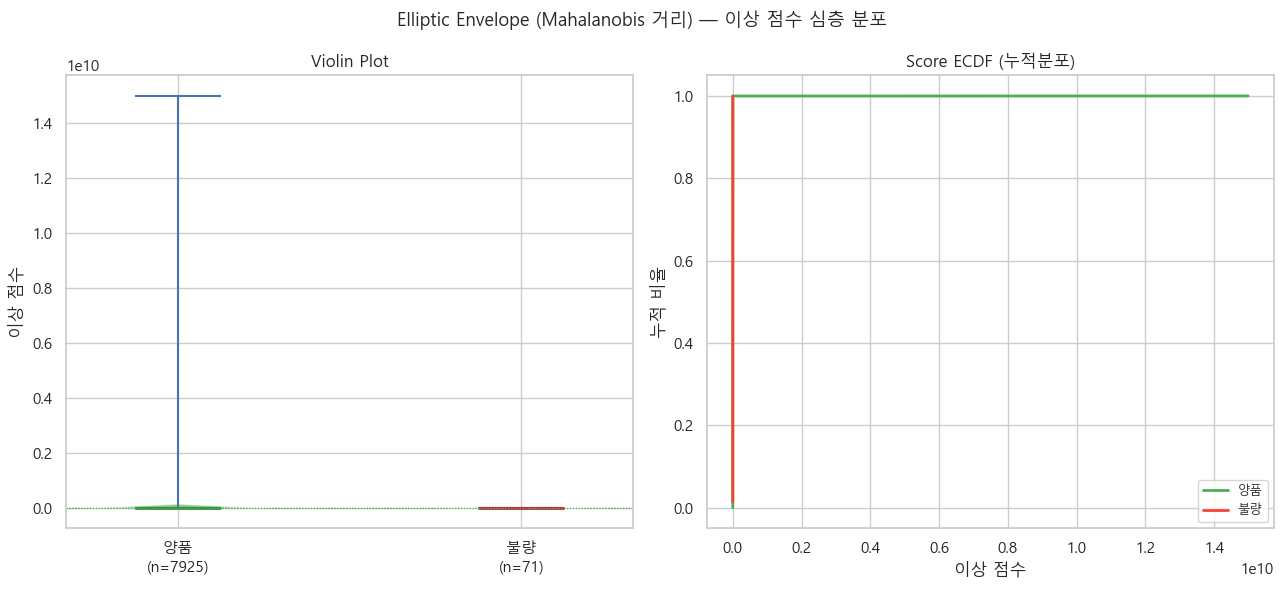

In [11]:
fig,axes=plt.subplots(1,2,figsize=(13,6))
fig.suptitle(f'{NB_NAME} — 이상 점수 심층 분포',fontsize=13)
vp=axes[0].violinplot([sc_lab[mask_n],sc_lab[mask_d]],showmedians=True,showextrema=True)
for pc,clr in zip(vp['bodies'],['#4CAF50','#F44336']):
    pc.set_facecolor(clr); pc.set_alpha(0.65)
vp['cmedians'].set_colors(['#388E3C','#C62828']); vp['cmedians'].set_linewidth(2)
axes[0].set_xticks([1,2]); axes[0].set_xticklabels([f'양품\n(n={mask_n.sum()})',f'불량\n(n={mask_d.sum()})'])
axes[0].set_ylabel('이상 점수'); axes[0].set_title('Violin Plot')
for pct in [25,50,75]:
    axes[0].axhline(np.percentile(sc_lab[mask_n],pct),color='#4CAF50',ls=':',lw=0.8)
for data,lbl,clr in [(sc_lab[mask_n],'양품','#4CAF50'),(sc_lab[mask_d],'불량','#F44336')]:
    x=np.sort(data); y=np.arange(1,len(data)+1)/len(data)
    axes[1].plot(x,y,color=clr,lw=2,label=lbl)
axes[1].set_xlabel('이상 점수'); axes[1].set_ylabel('누적 비율')
axes[1].set_title('Score ECDF (누적분포)'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_violin.png',dpi=150,bbox_inches='tight')
plt.show()

## 7d. 임계값 분석 (Precision-Recall Trade-off)

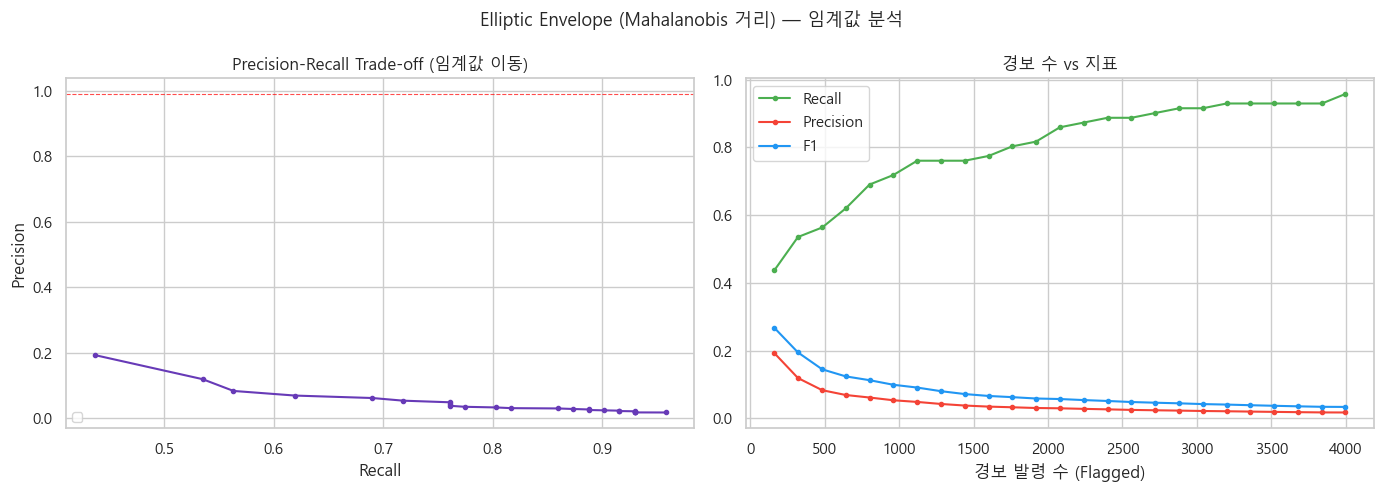


▶ 최적 F1 임계값: Flagged=161  Prec=0.1925  Rec=0.4366  F1=0.2672


In [12]:
thrs=np.percentile(sc_lab,np.arange(50,100,2))
res=[]
for thr in thrs:
    pred=(sc_lab>=thr).astype(int)
    tp=((pred==1)&(y_lab==1)).sum(); fp=((pred==1)&(y_lab==0)).sum()
    fn=((pred==0)&(y_lab==1)).sum()
    pr_t=tp/(tp+fp+1e-9); rc_t=tp/(tp+fn+1e-9)
    f1=2*pr_t*rc_t/(pr_t+rc_t+1e-9)
    res.append({'thr':thr,'Flagged':pred.sum(),'Prec':pr_t,'Rec':rc_t,'F1':f1,'TP':tp})
res_df=pd.DataFrame(res)
fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle(f'{NB_NAME} — 임계값 분석',fontsize=13)
axes[0].plot(res_df['Rec'],res_df['Prec'],'-o',ms=3,color='#673AB7',lw=1.5)
hp=res_df[res_df['Prec']>=0.99]
if len(hp):
    r=hp.iloc[-1]
    axes[0].plot(r['Rec'],r['Prec'],'r*',ms=14,zorder=5,label=f"Prec≥0.99→Rec={r['Rec']:.3f}(TP={int(r['TP'])})")
axes[0].axhline(0.99,color='red',ls='--',lw=0.8,alpha=0.7)
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Trade-off (임계값 이동)'); axes[0].legend(fontsize=9)
axes[1].plot(res_df['Flagged'],res_df['Rec'],'-o',ms=3,color='#4CAF50',label='Recall')
axes[1].plot(res_df['Flagged'],res_df['Prec'],'-o',ms=3,color='#F44336',label='Precision')
axes[1].plot(res_df['Flagged'],res_df['F1'],'-o',ms=3,color='#2196F3',label='F1')
axes[1].set_xlabel('경보 발령 수 (Flagged)'); axes[1].set_title('경보 수 vs 지표'); axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_threshold.png',dpi=150,bbox_inches='tight')
plt.show()
best_f1_row=res_df.loc[res_df['F1'].idxmax()]
print(f"\n▶ 최적 F1 임계값: Flagged={int(best_f1_row['Flagged'])}  Prec={best_f1_row['Prec']:.4f}  Rec={best_f1_row['Rec']:.4f}  F1={best_f1_row['F1']:.4f}")

## 8. 피처별 이상 점수 상관 분석

피처별 이상 점수 상관 분석

  순위   피처                                   Pearson r  방향
  -------------------------------------------------------
  1    Cushion_Position                       -0.9995  이상점수↑=불량감소
  2    Barrel_Temperature_1                   -0.7196  이상점수↑=불량감소
  3    Hopper_Temperature                     -0.4085  이상점수↑=불량감소
  4    Max_Screw_RPM                          -0.3581  이상점수↑=불량감소
  5    Mold_Temperature_3                     -0.2976  이상점수↑=불량감소
  6    Mold_Temperature_4                     -0.2743  이상점수↑=불량감소
  7    Barrel_Temperature_6                   +0.2725  이상점수↑=불량증가
  8    Clamp_Close_Time                       -0.2209  이상점수↑=불량감소
  9    Average_Back_Pressure                  -0.1638  이상점수↑=불량감소
  10   Cycle_Time                             +0.1246  이상점수↑=불량증가
  11   Max_Back_Pressure                      -0.0873  이상점수↑=불량감소
  12   Max_Injection_Pressure                 -0.0591  이상점수↑=불량감소
  13   Plasticizing_Time                      -0.0578  이상점수↑=불량감소
  14   Ba

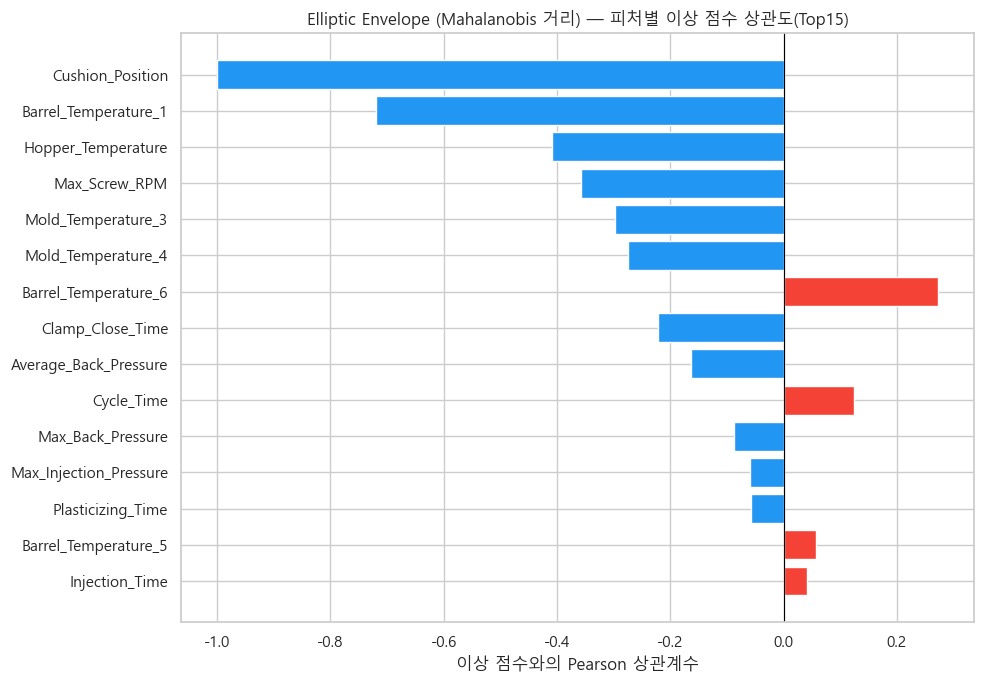

피처 상관 저장 완료


In [13]:
print("="*60); print("피처별 이상 점수 상관 분석"); print("="*60)
corrs = [(fcols[i], np.corrcoef(X_lab[:,i], sc_lab)[0,1]) for i in range(len(fcols))]
corr_df = pd.DataFrame(corrs, columns=['Feature','Corr'])
corr_df = corr_df.reindex(corr_df['Corr'].abs().sort_values(ascending=False).index).reset_index(drop=True)
print(f"\n  {'순위':<4} {'피처':<35} {'Pearson r':>10}  {'방향'}")
print("  "+"-"*55)
for rank,row in corr_df.iterrows():
    if abs(row['Corr'])<0.03: break
    print(f"  {rank+1:<4} {row['Feature']:<35} {row['Corr']:>+10.4f}  {'이상점수↑=불량증가' if row['Corr']>0 else '이상점수↑=불량감소'}")

top15=corr_df.head(15)
fig,ax=plt.subplots(figsize=(10,7))
colors=['#F44336' if v>0 else '#2196F3' for v in top15['Corr']]
ax.barh(top15['Feature'][::-1],top15['Corr'][::-1],color=colors[::-1],edgecolor='white')
ax.axvline(0,color='black',lw=0.8)
ax.set_xlabel('이상 점수와의 Pearson 상관계수')
ax.set_title(f'{NB_NAME} — 피처별 이상 점수 상관도(Top15)')
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_feat_corr.png',dpi=150,bbox_inches='tight')
plt.show(); print("피처 상관 저장 완료")

## 8b. 병렬 좌표계 (상위이상 vs 불량 vs 양품)

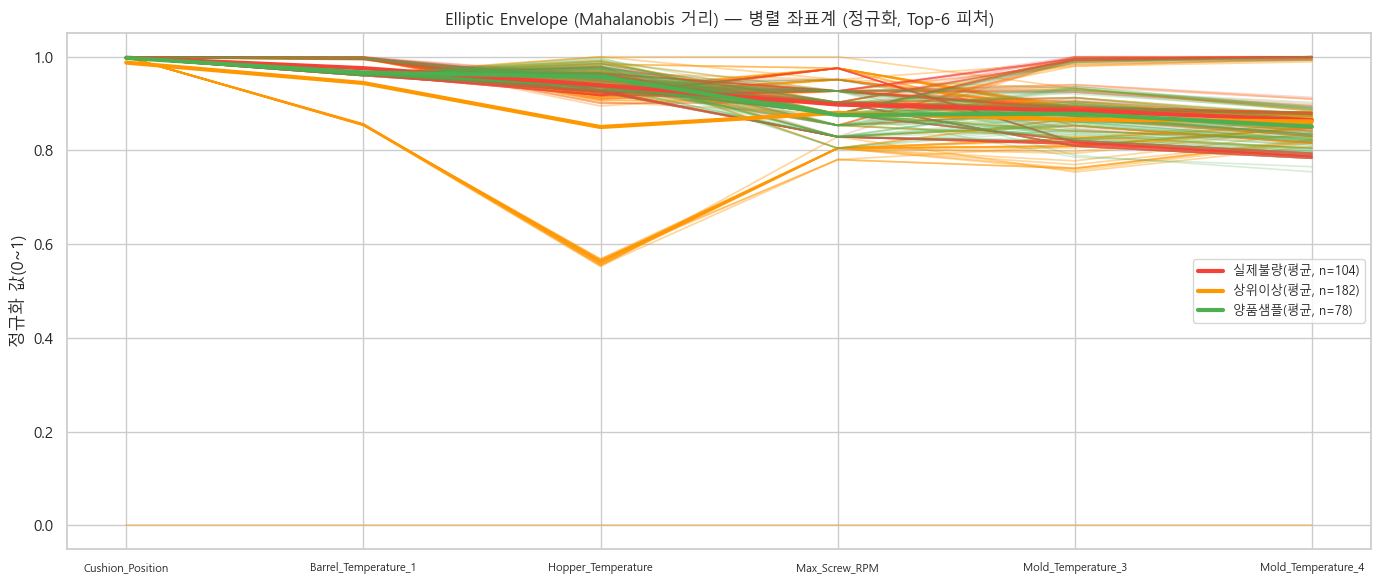

병렬 좌표계 저장 완료


In [14]:
top6f=corr_df.head(6)['Feature'].tolist(); top6f=[f for f in top6f if f in fcols][:6]
n_top_p=max(int(DR*len(y_lab))*3,30)
top_idx_p=np.argsort(sc_lab)[-n_top_p:]
rng_p=np.random.RandomState(SEED)
norm_samp=rng_p.choice(np.where(mask_n)[0],min(80,mask_n.sum()),replace=False)
rows_p=[]
for i in list(top_idx_p)+list(np.where(mask_d)[0])+list(norm_samp):
    grp='실제불량' if y_lab[i]==1 else ('상위이상' if i in top_idx_p else '양품샘플')
    rows_p.append({f:X_lab[i,fcols.index(f)] for f in top6f}|{'그룹':grp})
par_df=pd.DataFrame(rows_p)
for f in top6f:
    mn,mx=par_df[f].min(),par_df[f].max()
    par_df[f]=(par_df[f]-mn)/(mx-mn+1e-9)
fig,ax=plt.subplots(figsize=(14,6))
colors_p={'실제불량':'#F44336','상위이상':'#FF9800','양품샘플':'#4CAF50'}
for grp,gdf in par_df.groupby('그룹'):
    for _,row in gdf.iterrows():
        ax.plot(top6f,row[top6f].values,color=colors_p[grp],alpha=0.22,lw=1.2)
for grp,clr in colors_p.items():
    gdf=par_df[par_df['그룹']==grp]
    if len(gdf): ax.plot(top6f,gdf[top6f].mean().values,color=clr,lw=3,
                          label=f'{grp}(평균, n={len(gdf)})')
ax.set_title(f'{NB_NAME} — 병렬 좌표계 (정규화, Top-6 피처)',fontsize=12)
ax.legend(fontsize=9); ax.tick_params(axis='x',labelsize=8); ax.set_ylabel('정규화 값(0~1)')
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_parallel.png',dpi=150,bbox_inches='tight')
plt.show()
print("병렬 좌표계 저장 완료")

## 8c. 피처 평균 히트맵 (이상점수 분위별)

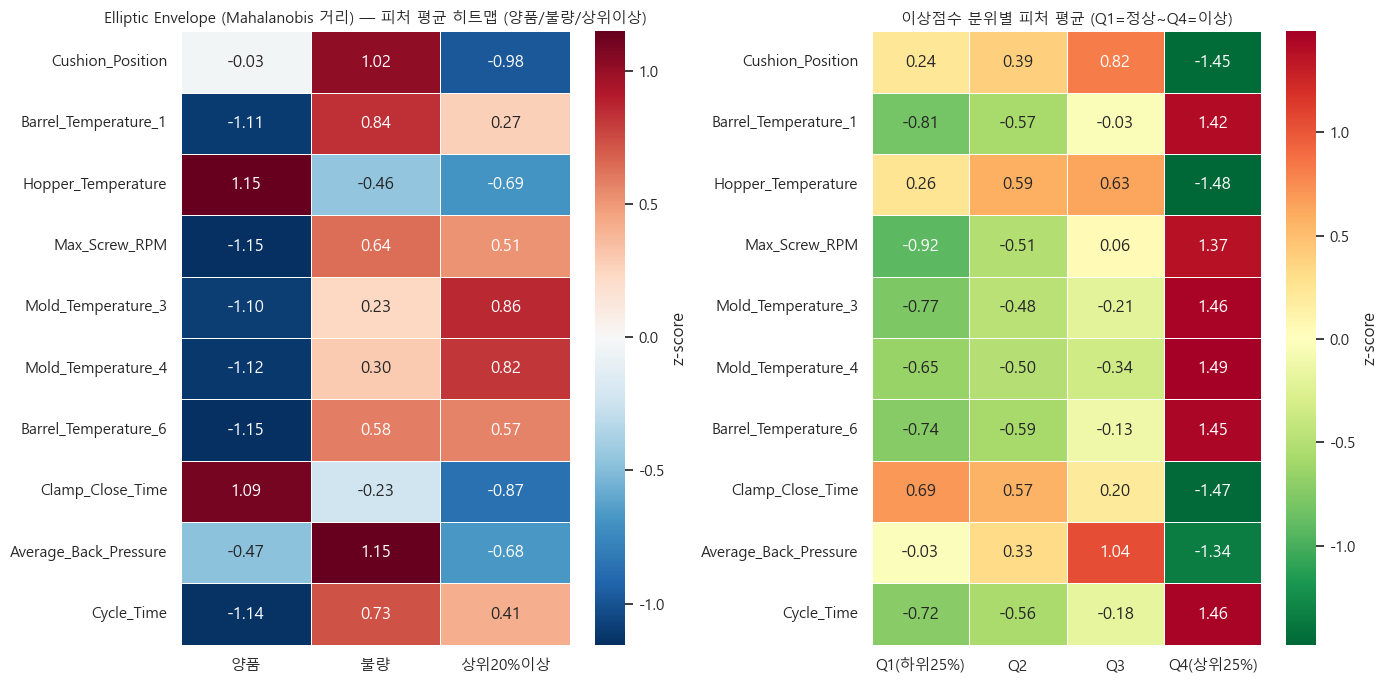

히트맵 저장 완료


In [15]:
top10f=corr_df.head(10)['Feature'].tolist()
top10idx_c=[fcols.index(f) for f in top10f]
thr80=np.percentile(sc_lab,80); hi_sc=sc_lab>=thr80
heat=pd.DataFrame({
    '양품':X_lab[mask_n][:,top10idx_c].mean(axis=0),
    '불량':X_lab[mask_d][:,top10idx_c].mean(axis=0),
    '상위20%이상':X_lab[hi_sc][:,top10idx_c].mean(axis=0) if hi_sc.sum()>0 else np.zeros(len(top10f)),
},index=top10f)
heat_z=heat.apply(lambda r:(r-r.mean())/(r.std()+1e-9),axis=1)
q_groups={}
for pct_lo,pct_hi,lbl in [(0,25,'Q1(하위25%)'),(25,50,'Q2'),(50,75,'Q3'),(75,100,'Q4(상위25%)')]:
    lo_=np.percentile(sc_lab,pct_lo); hi_=np.percentile(sc_lab,pct_hi)
    mq=(sc_lab>=lo_)&(sc_lab<hi_) if pct_hi<100 else sc_lab>=lo_
    if mq.sum()>0: q_groups[lbl]=X_lab[mq][:,top10idx_c].mean(axis=0)
q_df=pd.DataFrame(q_groups,index=top10f)
q_z=q_df.apply(lambda r:(r-r.mean())/(r.std()+1e-9),axis=1)
fig,axes=plt.subplots(1,2,figsize=(14,7))
sns.heatmap(heat_z,annot=True,fmt='.2f',cmap='RdBu_r',center=0,ax=axes[0],linewidths=0.5,
            cbar_kws={'label':'z-score'})
axes[0].set_title(f'{NB_NAME} — 피처 평균 히트맵 (양품/불량/상위이상)',fontsize=11); axes[0].set_ylabel('')
sns.heatmap(q_z,annot=True,fmt='.2f',cmap='RdYlGn_r',center=0,ax=axes[1],linewidths=0.5,
            cbar_kws={'label':'z-score'})
axes[1].set_title('이상점수 분위별 피처 평균 (Q1=정상~Q4=이상)',fontsize=11); axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()
print("히트맵 저장 완료")

## 9. 상위 이상 샘플 분석 + Labeled 불량 비교

상위 71개 이상 샘플 분석 (DR=0.89%)

▶ 상위 71개 중 실제 불량: 22개
  Precision@71: 0.3099
  Recall   @71: 0.3099 (22/71개 탐지)

▶ 방향일치도: 7/25 피처 = 28% (50%=무작위, 100%=완전일치)

▶ 피처별 비교 (|차이|>50% 피처):
  피처                                  Top이상평균       불량평균       양품평균  일치
  ----------------------------------------------------------------------
  Injection_Time                        10.99       6.15       8.26   ✗
  Switch_Over_Position                   0.28       0.00       0.33   ✓
  Average_Screw_RPM                    125.68     258.39     148.04   ✗


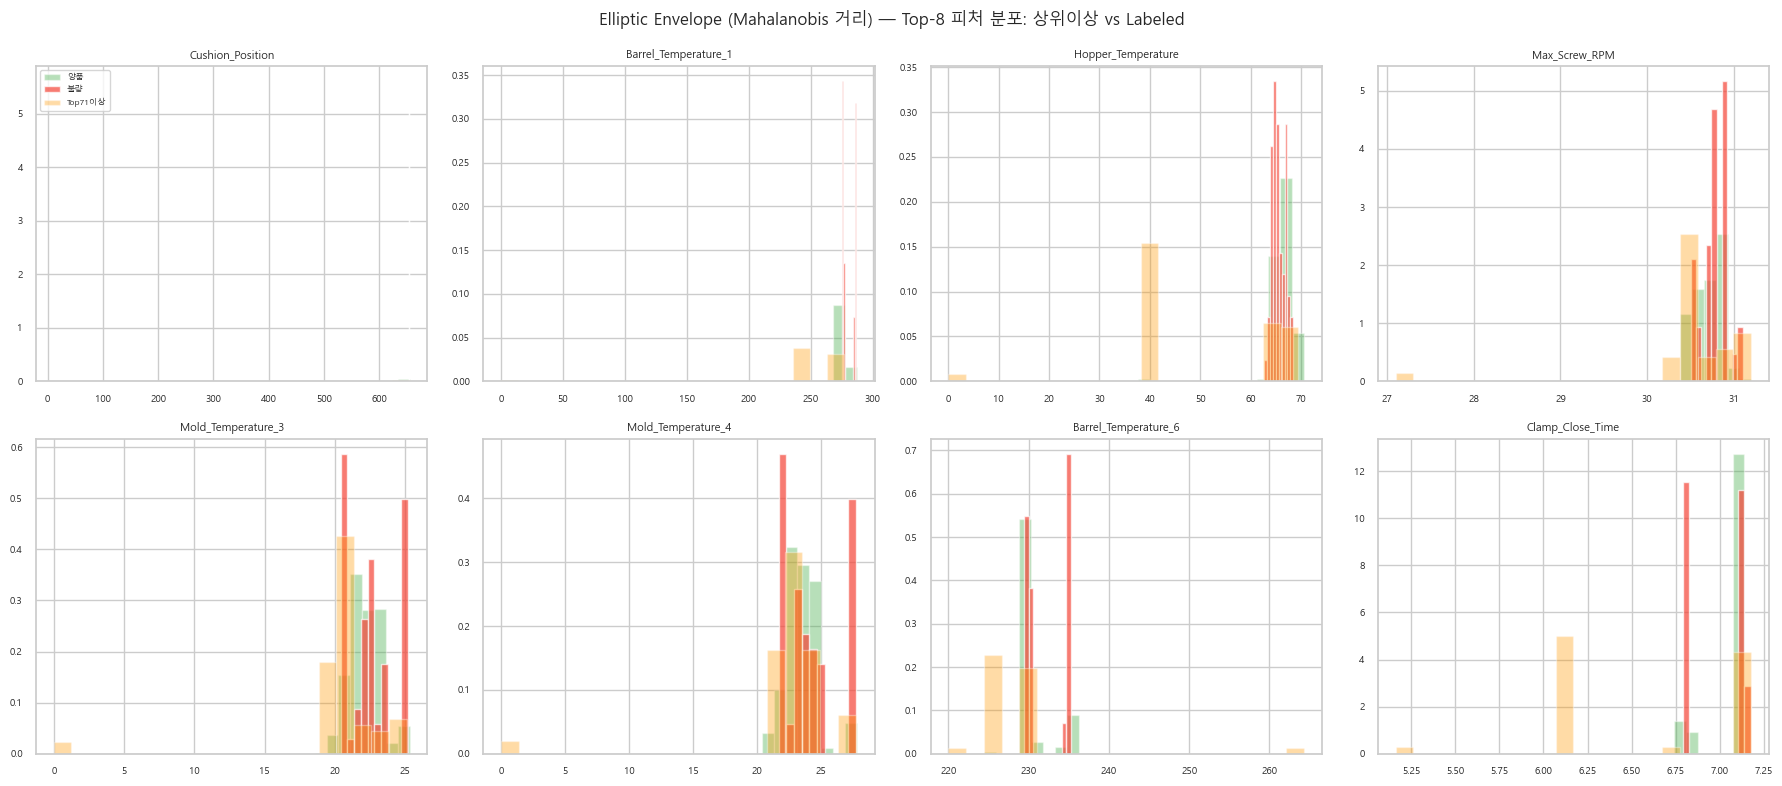

상위 이상 분포 저장 완료


In [16]:
n_top = max(int(DR*len(y_lab)),10)
top_idx = np.argsort(sc_lab)[-n_top:][::-1]
hit = y_lab[top_idx].sum()
print("="*60); print(f"상위 {n_top}개 이상 샘플 분석 (DR={DR*100:.2f}%)"); print("="*60)
print(f"\n▶ 상위 {n_top}개 중 실제 불량: {hit}개")
print(f"  Precision@{n_top}: {hit/n_top:.4f}")
print(f"  Recall   @{n_top}: {hit/mask_d.sum():.4f} ({hit}/{mask_d.sum()}개 탐지)")

comp=pd.DataFrame({
    f'Top{n_top}이상 평균': X_lab[top_idx].mean(axis=0),
    '불량 평균'           : X_lab[mask_d].mean(axis=0),
    '양품 평균'           : X_lab[mask_n].mean(axis=0),
},index=fcols)
comp['방향일치'] = ((comp[f'Top{n_top}이상 평균']-comp['양품 평균'])*(comp['불량 평균']-comp['양품 평균'])>0)
n_match = comp['방향일치'].sum()
print(f"\n▶ 방향일치도: {n_match}/25 피처 = {n_match/25*100:.0f}% (50%=무작위, 100%=완전일치)")

print(f"\n▶ 피처별 비교 (|차이|>50% 피처):")
print(f"  {'피처':<32} {'Top이상평균':>10} {'불량평균':>10} {'양품평균':>10}  {'일치'}")
print("  "+"-"*70)
for feat in fcols:
    tv=comp.loc[feat,f'Top{n_top}이상 평균']; dv=comp.loc[feat,'불량 평균']; nv=comp.loc[feat,'양품 평균']
    diff_pct = abs(tv-dv)/(abs(dv)+1e-9)*100
    if diff_pct>50:
        m='✓' if comp.loc[feat,'방향일치'] else '✗'
        print(f"  {feat:<32} {tv:10.2f} {dv:10.2f} {nv:10.2f}   {m}")

# Top 이상 점수 vs 불량/양품 분포 (top-8 피처)
top8=corr_df.head(8)['Feature'].tolist()
fig,axes=plt.subplots(2,4,figsize=(18,8))
fig.suptitle(f'{NB_NAME} — Top-8 피처 분포: 상위이상 vs Labeled',fontsize=12)
for ax,feat in zip(axes.flatten(),top8):
    fi=fcols.index(feat)
    ax.hist(X_lab[mask_n,fi],bins=30,alpha=0.4,color='#4CAF50',density=True,label='양품')
    ax.hist(X_lab[mask_d,fi],bins=10,alpha=0.7,color='#F44336',density=True,label='불량')
    ax.hist(X_lab[top_idx,fi],bins=20,alpha=0.35,color='#FF9800',density=True,label=f'Top{n_top}이상')
    ax.set_title(feat,fontsize=8); ax.tick_params(labelsize=7)
    if feat==top8[0]: ax.legend(fontsize=6)
plt.tight_layout()
plt.savefig(FIG_DIR/f'{NB_PRE}_fig_top_anomaly.png',dpi=150,bbox_inches='tight')
plt.show(); print("상위 이상 분포 저장 완료")

## 10. Elliptic Envelope (Mahalanobis 거리) — 방법 특화 심층 분석

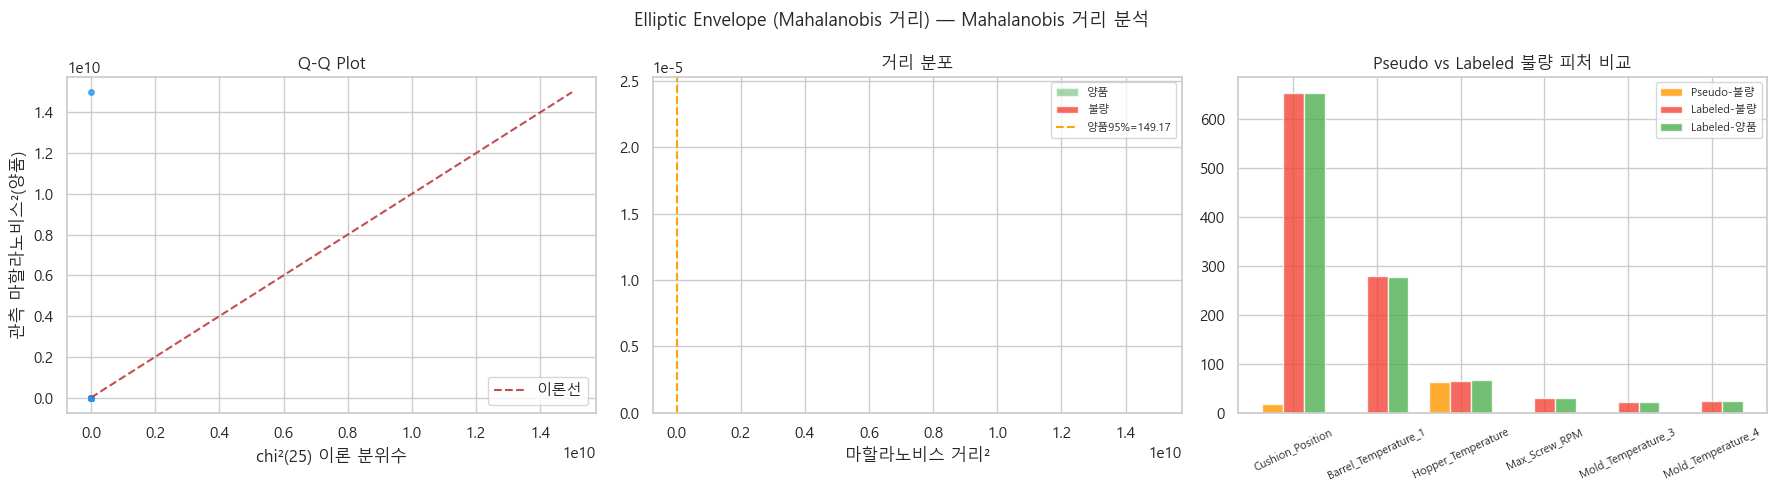

Mahalanobis Q-Q 저장 완료


In [17]:
try:
    from scipy.stats import chi2 as _chi2
    maha_sq=clf.mahalanobis(Xl)
    n_dim=Xl.shape[1]
    sorted_m=np.sort(maha_sq[mask_n])
    chi2_th=_chi2.ppf(np.linspace(0.01,0.99,len(sorted_m)),df=n_dim)
    fig,axes=plt.subplots(1,3,figsize=(18,5))
    fig.suptitle(f'{NB_NAME} — Mahalanobis 거리 분석',fontsize=13)
    axes[0].scatter(chi2_th,sorted_m,alpha=0.5,s=15,color='#2196F3')
    mn_=min(chi2_th.min(),sorted_m.min()); mx_=max(chi2_th.max(),sorted_m.max())
    axes[0].plot([mn_,mx_],[mn_,mx_],'r--',lw=1.5,label='이론선')
    axes[0].set_xlabel(f'chi²({n_dim}) 이론 분위수')
    axes[0].set_ylabel('관측 마할라노비스²(양품)'); axes[0].set_title('Q-Q Plot'); axes[0].legend()
    axes[1].hist(maha_sq[mask_n],bins=40,alpha=0.5,color='#4CAF50',density=True,label=f'양품')
    axes[1].hist(maha_sq[mask_d],bins=10,alpha=0.8,color='#F44336',density=True,label=f'불량')
    th95=np.percentile(maha_sq[mask_n],95)
    axes[1].axvline(th95,color='orange',ls='--',lw=1.5,label=f'양품95%={th95:.2f}')
    axes[1].set_xlabel('마할라노비스 거리²'); axes[1].set_title('거리 분포'); axes[1].legend(fontsize=8)
    top6_ee=[f for f in corr_df.head(6)['Feature'].tolist() if f in fcols][:6]
    top6i_ee=[fcols.index(f) for f in top6_ee]
    pm=X_unl[pseudo_d][:,top6i_ee].mean(axis=0) if pseudo_d.sum()>0 else np.zeros(len(top6_ee))
    dm=X_lab[mask_d][:,top6i_ee].mean(axis=0); nm=X_lab[mask_n][:,top6i_ee].mean(axis=0)
    x_=np.arange(len(top6_ee)); w=0.25
    axes[2].bar(x_-w,pm,w,label='Pseudo-불량',color='#FF9800',alpha=0.8)
    axes[2].bar(x_,dm,w,label='Labeled-불량',color='#F44336',alpha=0.8)
    axes[2].bar(x_+w,nm,w,label='Labeled-양품',color='#4CAF50',alpha=0.8)
    axes[2].set_xticks(x_); axes[2].set_xticklabels(top6_ee,rotation=25,fontsize=8)
    axes[2].set_title('Pseudo vs Labeled 불량 피처 비교'); axes[2].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR/f'{NB_PRE}_fig_mahal.png',dpi=150,bbox_inches='tight')
    plt.show(); print("Mahalanobis Q-Q 저장 완료")
except Exception as e:
    print(f"Q-Q 실패: {e}")